### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform data preprocessing for image classification tasks

### Contents
1. Section 1 : Loading Dataset
2. Section 2 : Exploratory Data Analysis

### Library Imports

In [1]:
!pip install opencv-python --quiet

In [2]:
!pip install numpy

In [3]:
# Importing required libraries and setting global variables
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [4]:
dataset_path = './25675238/Image_Classification/dataset'
data_files_path = './data_files/Image_Classification'

### Section 1 : Loading Dataset

In [ ]:
# Renaming folder names to lowercase # This operation is for one-time execution
# for folder in classes:
#     folder_path = os.path.join(dataset_path, folder)
#     new_path = os.path.join(dataset_path, folder.lower())
#     os.rename(folder_path, new_path)

In [5]:
classes = os.listdir(dataset_path)

In [6]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk -F'/' '{printf "%-30s : %s images\n", $NF, $1}'

bernese_mountain_dog           :     218 . images
borzoi                         :     151 . images
brittany_spaniel               :     152 . images
chihuahua                      :     152 . images
german_short-haired_pointer    :     152 . images
norwegian_elkhound             :     196 . images
schipperke                     :     154 . images
sussex_spaniel                 :     151 . images
toy_terrier                    :     172 . images
wire-haired_fox_terrier        :     157 . images


In [7]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 1655

### Section 2 : Exploratory Data Analysis

*In this section, we explore the characteristics of this dataset. We will use OpenCV library to access and examine the images*

*As shown in the previous sections, the dataset contains of 10 classes of dog images.*

*Each class consists of different number of images, bringing the total number of images to 1655.*

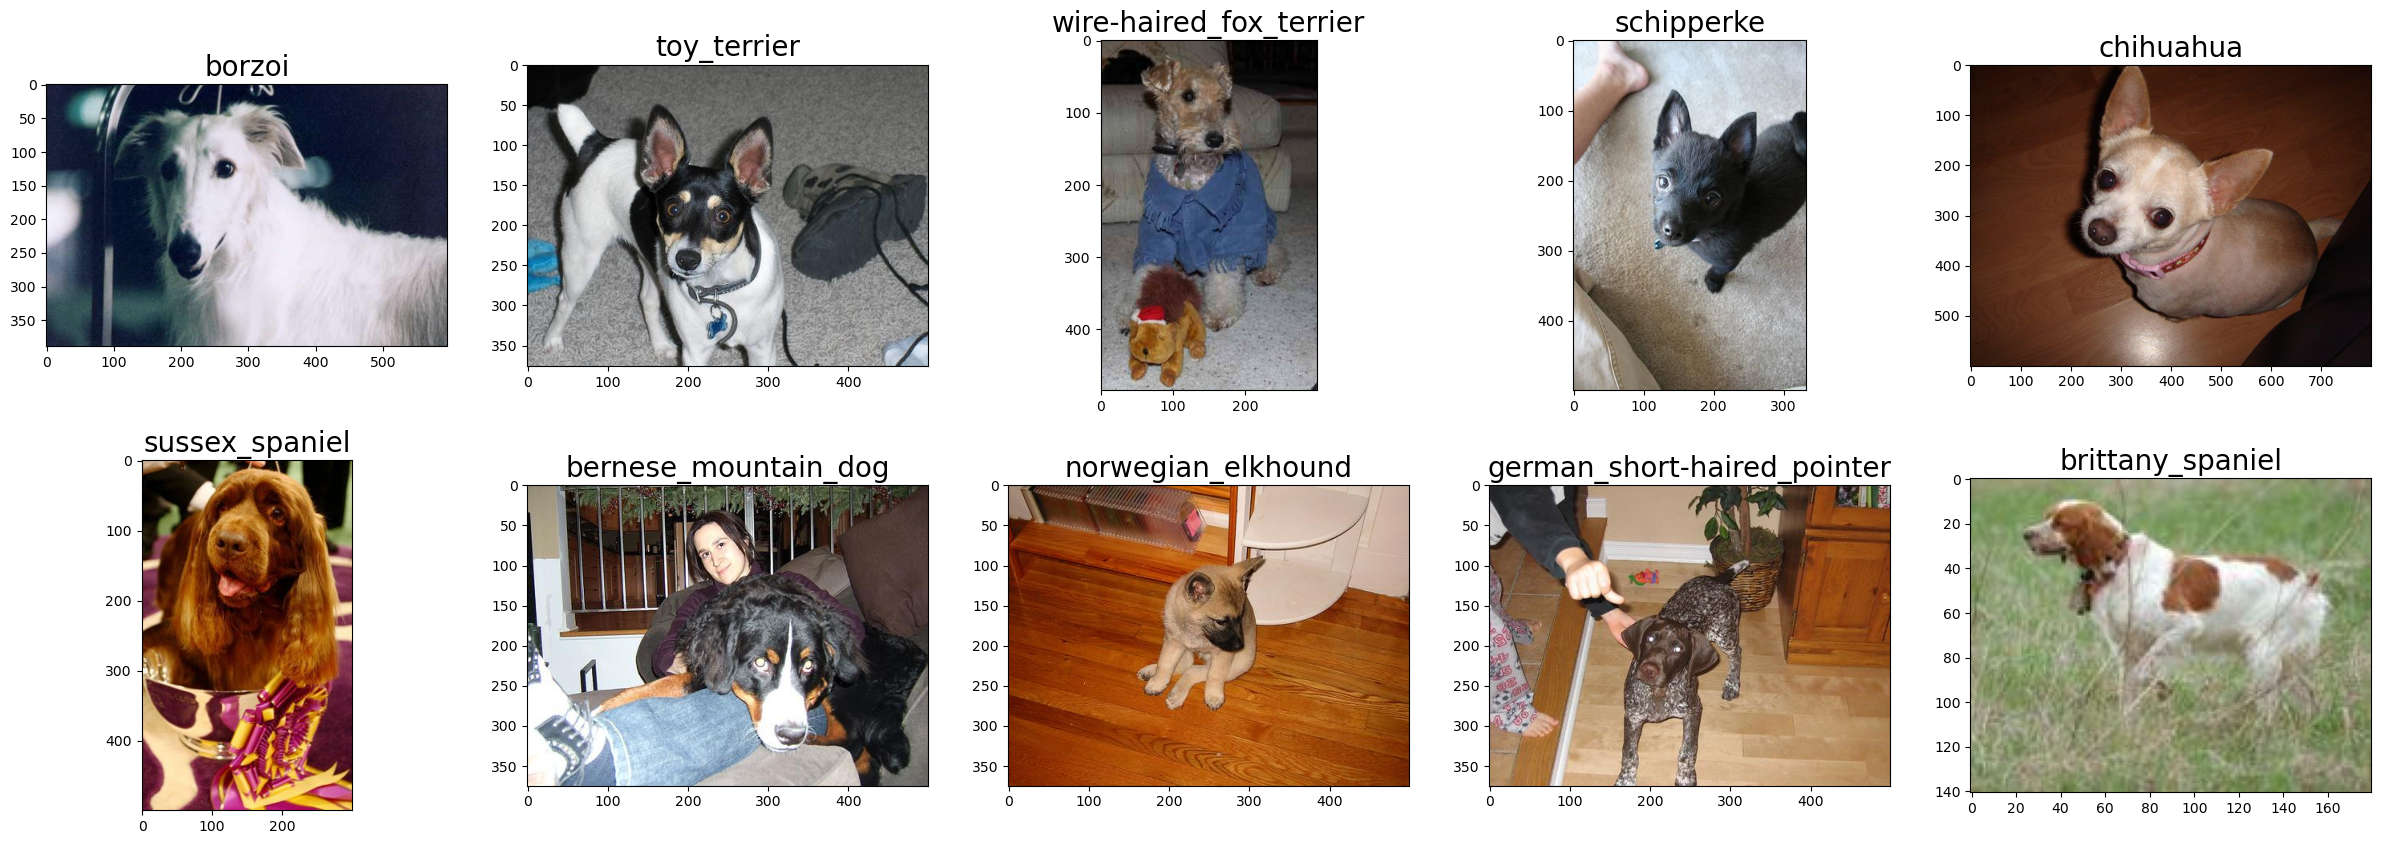

In [6]:
#Analysing images from every class

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30,10))
class_idx = 0
for i in range(2):
    for j in range(5):
        folder_path = dataset_path + "/" + classes[class_idx]
        images_path = os.listdir(folder_path)
        img_idx = random.randint(0, len(images_path) - 1) # Showing a random image for the same class on every run
        img = cv2.imread(folder_path + "/" + images_path[img_idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i,j].imshow(img)
        axes[i,j].set_title(classes[class_idx], fontsize=20)
        class_idx += 1
plt.show()

In [7]:
#Printing image shape
image = cv2.imread(dataset_path + '/bernese_mountain_dog/01.jpg')
print("Image dimensions :", image.shape)
print("Image data type :", image.dtype)
print("Image width :", image.shape[0])
print("Image length :", image.shape[1])

Image dimensions : (333, 500, 3)
Image data type : uint8
Image width : 333
Image length : 500


*It can be observed that the images have 3 (RGB) channels.*

All images analysed for class :  borzoi


All images analysed for class :  toy_terrier


All images analysed for class :  wire-haired_fox_terrier


All images analysed for class :  schipperke


All images analysed for class :  chihuahua


All images analysed for class :  sussex_spaniel


All images analysed for class :  bernese_mountain_dog


All images analysed for class :  norwegian_elkhound


All images analysed for class :  german_short-haired_pointer


All images analysed for class :  brittany_spaniel


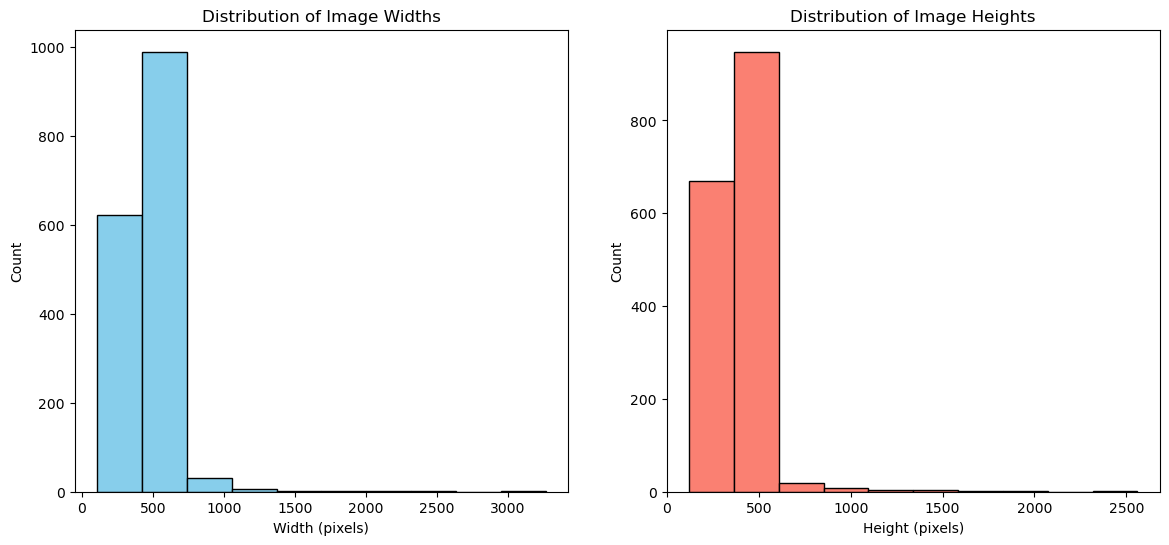

In [8]:
#Gathering image widths and heights and observing their distribution
widths = []
heights = []

#While traversing all images and labels, store them into separate arrays
#The images array will contain the image while the labels array will contain the class name as the label for that image
images = []
labels = []

for class_name in classes:
    folder_path = dataset_path + "/" + class_name
    images_path = os.listdir(folder_path)
    for i in images_path:
        img_path = folder_path + "/" + i
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

        images.append(img)
        labels.append(class_name)
    print("All images analysed for class : ", class_name)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Width Histogram
ax1.hist(widths, bins=10, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Image Widths')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Count')

# Height Histogram
ax2.hist(heights, bins=10, color='salmon', edgecolor='black')
ax2.set_title('Distribution of Image Heights')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Count')

plt.show()

*It can be observed that all images belonging to the 10 classes have varied heights and widths which requires further processing before ingesting them into the CNN model.*

*From the obove mentioned distribtion it can be seen that maximum images have heights and widths around 500px, which is a significantly larger image for CNN training*

In [9]:
#Writing the raw images and labels to .npy files for reuse
images_np_array = np.array(images, dtype=object)
labels_np_array = np.array(labels, dtype=object)

np.savez(data_files_path + '/original_images.npz', images_np_array)
np.savez(data_files_path + '/original_labels.npz', labels_np_array)